# Toxic Comment Classification

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

from sklearn.metrics import roc_auc_score, f1_score, classification_report, roc_curve

import numpy as np
import re
from collections import Counter
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import pickle

from visuals import *

### Dataset Loading

In [2]:
TEST_LABELS = pd.read_csv("jigsaw-toxic-comment-classification-challenge/test_labels.csv/test_labels.csv")
TRAIN_SET = pd.read_csv("jigsaw-toxic-comment-classification-challenge/train.csv/train.csv")
TEST_SET = pd.read_csv("jigsaw-toxic-comment-classification-challenge/test.csv/test.csv")

In [3]:
TEST_SET = pd.merge(TEST_SET, TEST_LABELS, on = "id", how = "inner")

In [4]:
TRAIN_SET.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
TEST_SET.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,":If you have a look back at the source, the in...",-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,I don't anonymously edit articles at all.,-1,-1,-1,-1,-1,-1


In [6]:
TRAIN_SET.shape, TEST_SET.shape

((159571, 8), (153164, 8))

### Train Set EDA

In [7]:
labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

#### Count of every class

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


a:\github_projects\toxic_comments_cls\visuals.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


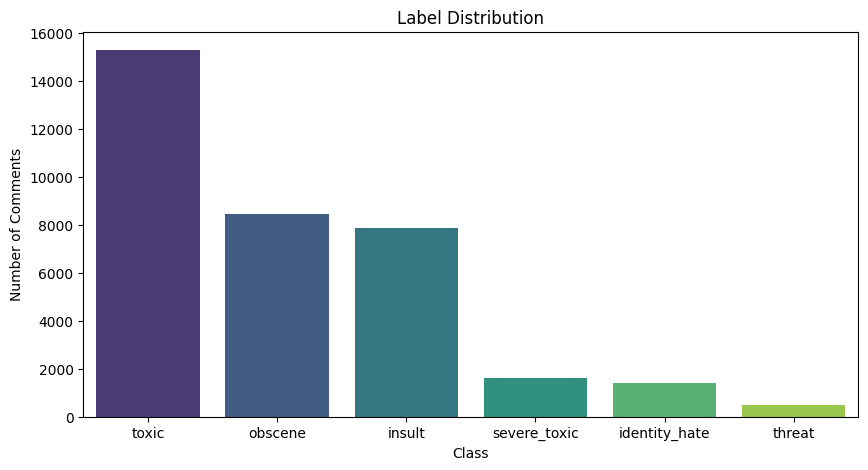

In [8]:
count_classes(TRAIN_SET, labels)

#### Percentage of every class

a:\github_projects\toxic_comments_cls\visuals.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


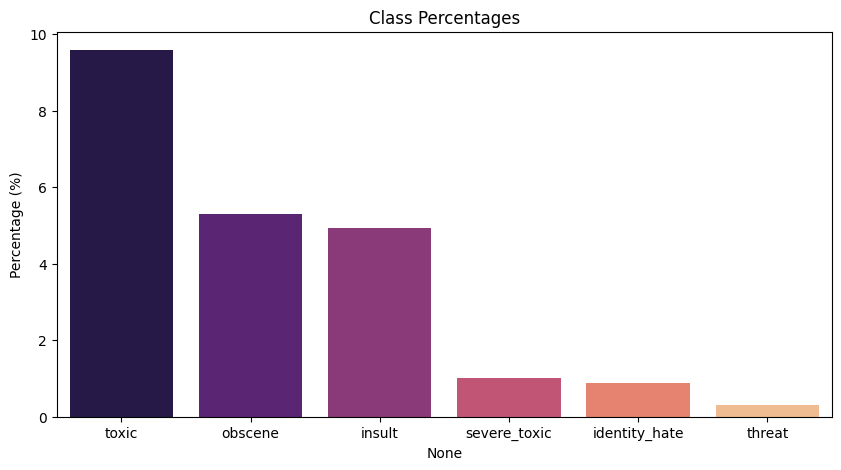

In [9]:
classes_percentage(TRAIN_SET, labels)

#### Total labels for each comment

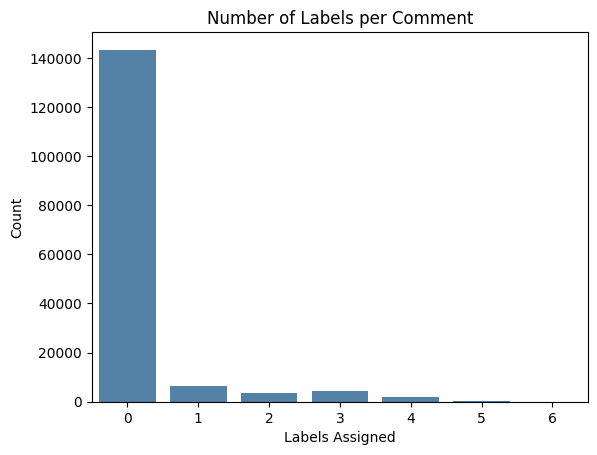

In [10]:
comment_labels_count(TRAIN_SET, labels)

#### Labels correlation

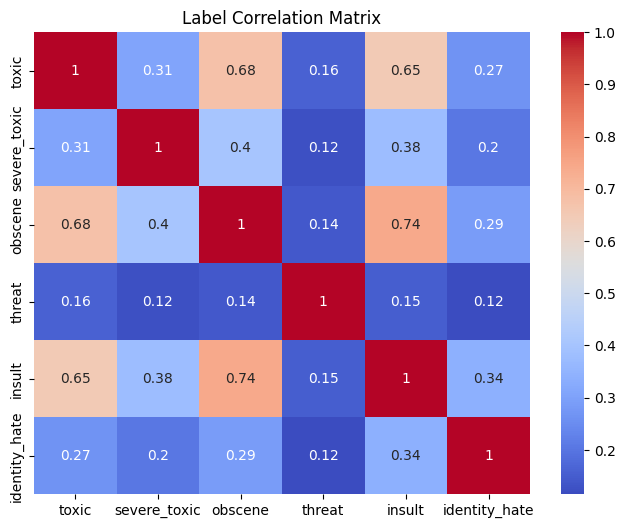

In [11]:
labels_corr(TRAIN_SET, labels)

#### Length of comments

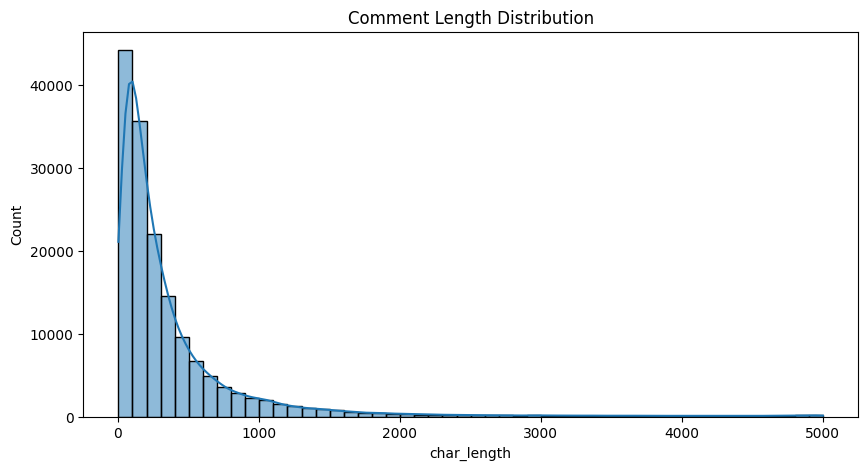

In [12]:
comment_len(TRAIN_SET, "comment_text")

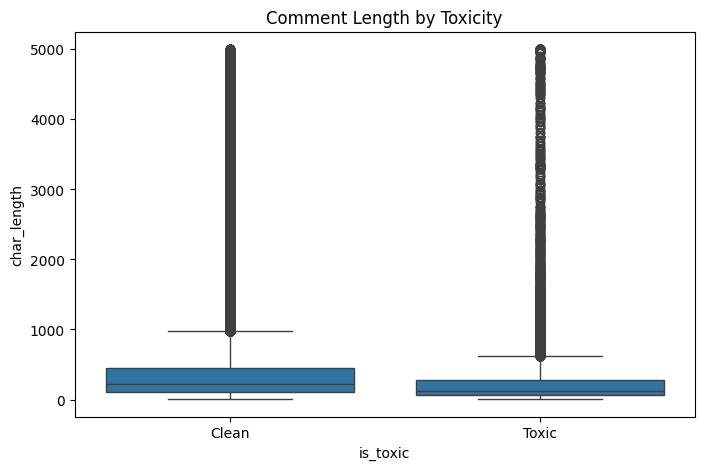

In [13]:
TRAIN_SET['is_toxic'] = (
    TRAIN_SET[labels].sum(axis=1) > 0
).astype(int)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_toxic',
    y='char_length',
    data=TRAIN_SET
)

plt.xticks([0,1], ['Clean', 'Toxic'])
plt.title("Comment Length by Toxicity")
plt.show()

In [14]:
TRAIN_SET.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels,char_length,is_toxic
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0,264,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0,112,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0,233,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0,622,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0,67,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0,0,65,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0,4,44,1
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0,0,115,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0,0,472,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0,0,70,0


### Dataset Pre-processing

#### Cleaning comments

In [15]:
lemmatizer = nltk.wordnet.WordNetLemmatizer()

def clean_comment(comment):
    comment = comment.lower()
    comment = re.sub(r'http\S+', '', comment)

    words = nltk.word_tokenize(comment)

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w.isalpha()
    ]

    return " ".join(words)

In [16]:
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LEGION\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LEGION\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
# Clean all the comments in the dataset
TRAIN_SET['comment'] = TRAIN_SET.apply(lambda r: clean_comment(r.comment_text), axis=1)
TRAIN_SET.drop('comment_text', inplace=True, axis=1)

TEST_SET['comment'] = TEST_SET.apply(lambda r: clean_comment(r.comment_text), axis=1)
TEST_SET.drop('comment_text', inplace=True, axis=1)

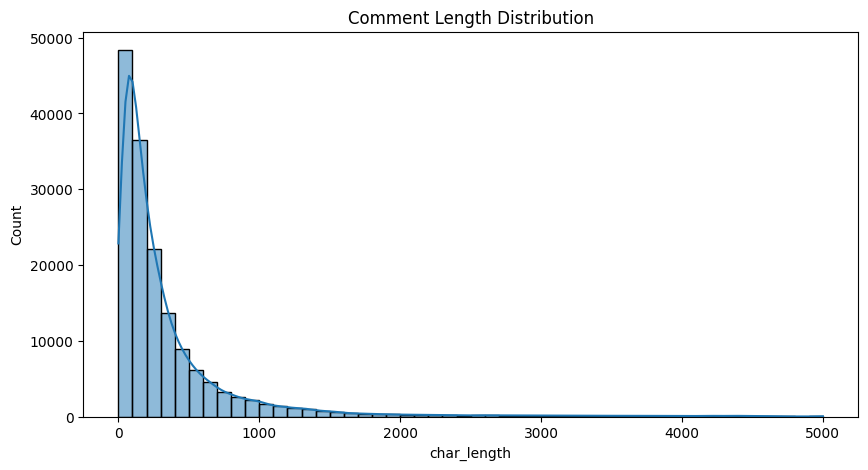

In [18]:
comment_len(TRAIN_SET, "comment")

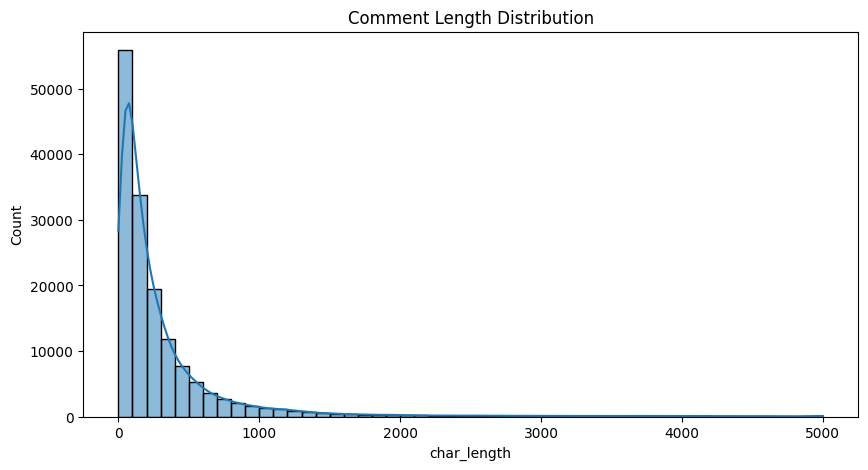

In [19]:
comment_len(TEST_SET, "comment")

#### Dropping columns

In [20]:
TRAIN_SET.head(10)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels,char_length,is_toxic,comment
0,0000997932d777bf,0,0,0,0,0,0,0,234,0,explanation why the edits made under my userna...
1,000103f0d9cfb60f,0,0,0,0,0,0,0,78,0,he match this background colour i seemingly st...
2,000113f07ec002fd,0,0,0,0,0,0,0,225,0,hey man i really not trying to edit war it jus...
3,0001b41b1c6bb37e,0,0,0,0,0,0,0,552,0,more i ca make any real suggestion on improvem...
4,0001d958c54c6e35,0,0,0,0,0,0,0,61,0,you sir are my hero any chance you remember wh...
5,00025465d4725e87,0,0,0,0,0,0,0,52,0,congratulation from me a well use the tool wel...
6,0002bcb3da6cb337,1,1,1,0,1,0,4,44,1,cocksucker before you piss around on my work
7,00031b1e95af7921,0,0,0,0,0,0,0,107,0,your vandalism to the matt shirvington article...
8,00037261f536c51d,0,0,0,0,0,0,0,419,0,sorry if the word wa offensive to you anyway i...
9,00040093b2687caa,0,0,0,0,0,0,0,70,0,alignment on this subject and which are contra...


In [21]:
# Remove id column
TRAIN_SET.drop(columns=TRAIN_SET.columns[[0, 7, 8, 9]], inplace=True)
TRAIN_SET.head(10)

,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment
0,0,0,0,0,0,0,explanation why the edits made under my userna...
1,0,0,0,0,0,0,he match this background colour i seemingly st...
2,0,0,0,0,0,0,hey man i really not trying to edit war it jus...
3,0,0,0,0,0,0,more i ca make any real suggestion on improvem...
4,0,0,0,0,0,0,you sir are my hero any chance you remember wh...
5,0,0,0,0,0,0,congratulation from me a well use the tool wel...
6,1,1,1,0,1,0,cocksucker before you piss around on my work
7,0,0,0,0,0,0,your vandalism to the matt shirvington article...
8,0,0,0,0,0,0,sorry if the word wa offensive to you anyway i...
9,0,0,0,0,0,0,alignment on this subject and which are contra...


In [22]:
TEST_SET.head(10)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment,char_length
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1,yo bitch ja rule is more succesful then you ev...,343
1,0000247867823ef7,-1,-1,-1,-1,-1,-1,from rfc the title is fine a it is imo,38
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1,source zawe ashton on lapland,29
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1,if you have a look back at the source the info...,196
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1,i do anonymously edit article at all,36
5,0001ea8717f6de06,0,0,0,0,0,0,thank you for understanding i think very highl...,94
6,00024115d4cbde0f,-1,-1,-1,-1,-1,-1,please do not add nonsense to wikipedia such e...,167
7,000247e83dcc1211,0,0,0,0,0,0,dear god this site is horrible,30
8,00025358d4737918,-1,-1,-1,-1,-1,-1,only a fool can believe in such number the cor...,457
9,00026d1092fe71cc,-1,-1,-1,-1,-1,-1,double redirects when fixing double redirects ...,204


In [23]:
TEST_SET.shape

(153164, 9)

In [24]:
TEST_SET = TEST_SET.where(TEST_SET['toxic'] != -1)
TEST_SET.dropna(inplace=True)
TEST_SET.shape

(63978, 9)

#### EDA on TEST SET

toxic            6090.0
obscene          3691.0
insult           3427.0
identity_hate     712.0
severe_toxic      367.0
threat            211.0
dtype: float64


a:\github_projects\toxic_comments_cls\visuals.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


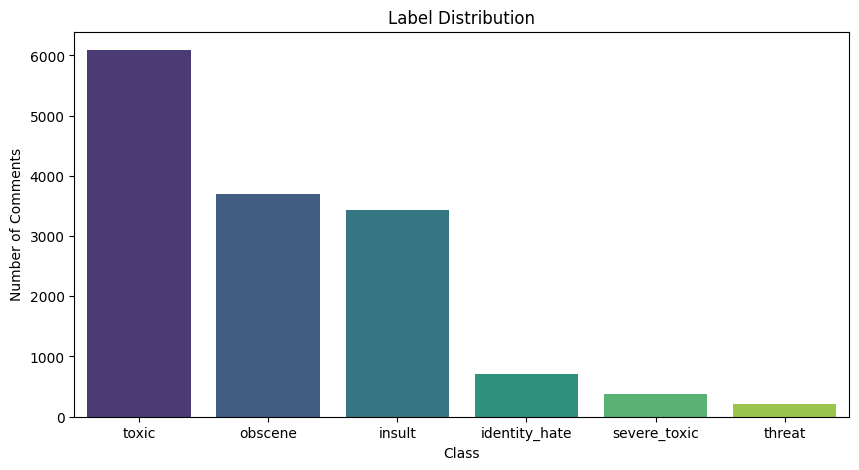

a:\github_projects\toxic_comments_cls\visuals.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


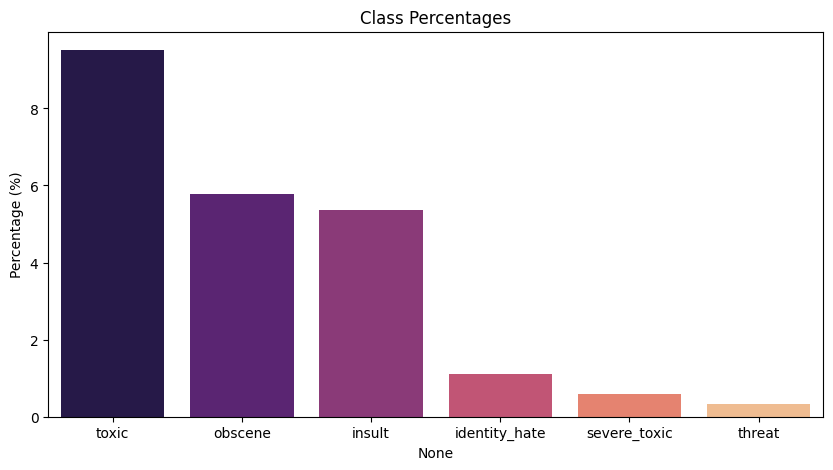

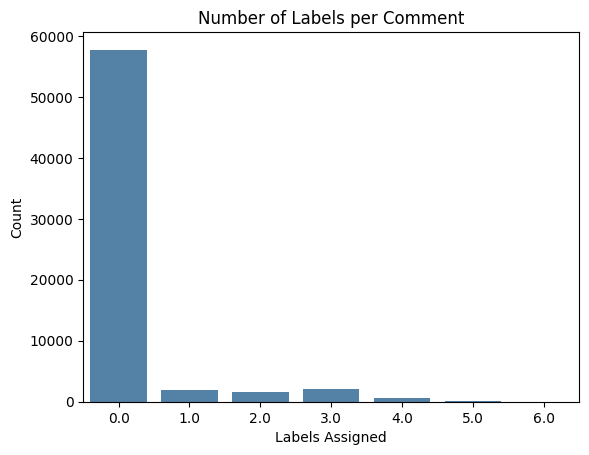

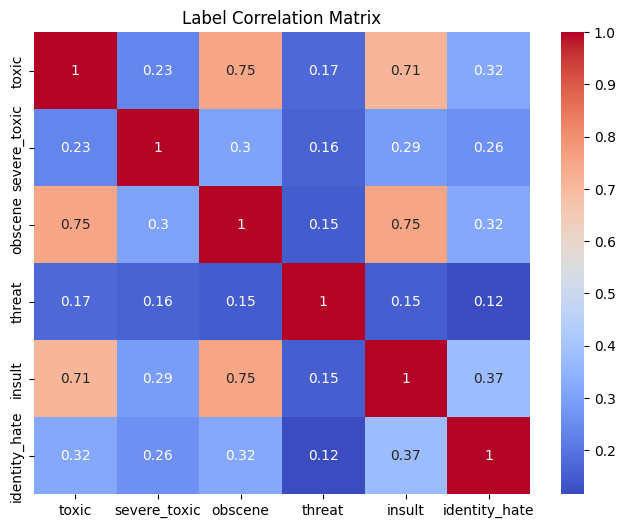

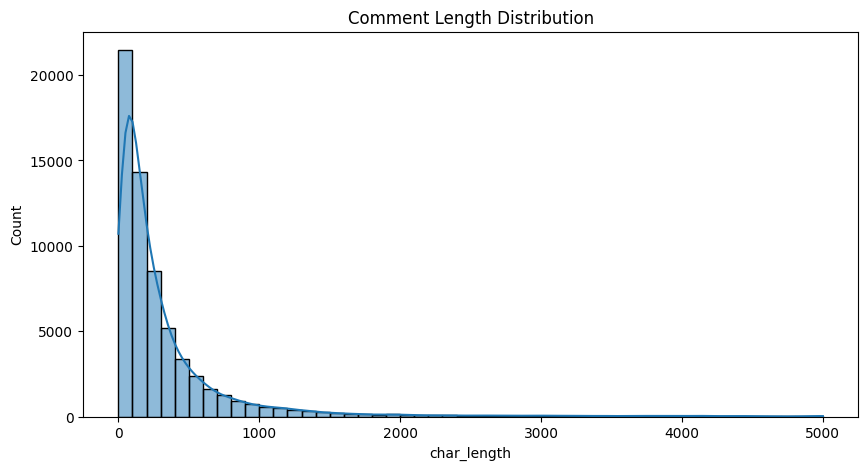

In [25]:
count_classes(TEST_SET, labels)
classes_percentage(TEST_SET, labels)
comment_labels_count(TEST_SET, labels)
labels_corr(TEST_SET, labels)
comment_len(TEST_SET, "comment")

In [26]:
TEST_SET.head(10)

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment,char_length,num_labels
5,0001ea8717f6de06,0.0,0.0,0.0,0.0,0.0,0.0,thank you for understanding i think very highl...,94,0.0
7,000247e83dcc1211,0.0,0.0,0.0,0.0,0.0,0.0,dear god this site is horrible,30,0.0
11,0002f87b16116a7f,0.0,0.0,0.0,0.0,0.0,0.0,somebody will invariably try to add religion r...,378,0.0
13,0003e1cccfd5a40a,0.0,0.0,0.0,0.0,0.0,0.0,it say it right there that it is a type the ty...,433,0.0
14,00059ace3e3e9a53,0.0,0.0,0.0,0.0,0.0,0.0,before adding a new product to the list make s...,300,0.0
16,000663aff0fffc80,0.0,0.0,0.0,0.0,0.0,0.0,this other one from,19,0.0
17,000689dd34e20979,0.0,0.0,0.0,0.0,0.0,0.0,reason for banning throwing this article need ...,127,0.0
19,000844b52dee5f3f,0.0,0.0,0.0,0.0,0.0,0.0,from editing wikipedia,22,0.0
21,00091c35fa9d0465,1.0,0.0,0.0,0.0,0.0,0.0,arab are committing genocide in iraq but no pr...,90,1.0
22,000968ce11f5ee34,0.0,0.0,0.0,0.0,0.0,0.0,please stop if you continue to vandalize wikip...,110,0.0


In [27]:
TEST_SET.drop(columns=TEST_SET.columns[[0, 8, 9]], inplace=True)

#### Modifying Datatypes

In [28]:
TEST_SET.dtypes

toxic            float64
severe_toxic     float64
obscene          float64
threat           float64
insult           float64
identity_hate    float64
comment           object
dtype: object

In [29]:
TRAIN_SET.dtypes

toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
comment          object
dtype: object

In [30]:
TEST_SET[labels] = TEST_SET[labels].astype(int)
TEST_SET.dtypes

toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
comment          object
dtype: object

In [31]:
type(TRAIN_SET["comment"].iloc[0]), type(TEST_SET["comment"].iloc[0])

(str, str)

### Continuous Bag of Words (CBoW)

#### 1. Creating CBoW Data

In [32]:
all_words = []

for comment in TRAIN_SET["comment"]:
    all_words.extend(comment.split())

word_counts = Counter(all_words)
vocab = [word for word, freq in word_counts.items() if freq >= 3]
print(f"Vocabulary Words: {vocab}")

word_to_idx = {word: i+1 for i, word in enumerate(vocab)}
word_to_idx["UNK"] = 0
print(f"Word to index: {word_to_idx}")

idx_to_word = {i: w for w, i in word_to_idx.items()}
print(f"Index to word: {idx_to_word}")

vocab_size = len(word_to_idx)
print(f"Vocabulary size: {vocab_size}")

Vocabulary Words: ['explanation', 'why', 'the', 'edits', 'made', 'under', 'my', 'username', 'hardcore', 'metallica', 'fan', 'were', 'reverted', 'they', 'vandalism', 'just', 'closure', 'on', 'some', 'gas', 'after', 'i', 'voted', 'at', 'new', 'york', 'doll', 'fac', 'and', 'please', 'do', 'remove', 'template', 'from', 'talk', 'page', 'since', 'retired', 'he', 'match', 'this', 'background', 'colour', 'seemingly', 'stuck', 'with', 'thanks', 'january', 'utc', 'hey', 'man', 'really', 'not', 'trying', 'to', 'edit', 'war', 'it', 'that', 'guy', 'is', 'constantly', 'removing', 'relevant', 'information', 'talking', 'me', 'through', 'instead', 'of', 'seems', 'care', 'more', 'about', 'formatting', 'than', 'actual', 'info', 'ca', 'make', 'any', 'real', 'suggestion', 'improvement', 'wondered', 'if', 'section', 'statistic', 'should', 'be', 'later', 'or', 'a', 'subsection', 'type', 'accident', 'think', 'reference', 'may', 'need', 'tidying', 'so', 'are', 'all', 'in', 'exact', 'same', 'format', 'ie', 'dat

In [33]:
def generate_cbow_data(comments, word_to_idx, window_size=2):
    cbow_data = []

    for comment in comments:
        words = comment.split()
        indexed_words = [word_to_idx.get(w, 0) for w in words]  # UNK=0

        for i, target in enumerate(indexed_words):
            context = []
            
            # left context
            for j in range(i - window_size, i):
                if j >= 0:
                    context.append(indexed_words[j])

            # right context
            for j in range(i + 1, i + window_size + 1):
                if j < len(indexed_words):
                    context.append(indexed_words[j])

            if len(context) > 0:
                cbow_data.append((context, target))

    return cbow_data

In [34]:
cbow_data = generate_cbow_data(TRAIN_SET['comment'].to_list(), word_to_idx)

In [35]:
len(cbow_data)

10336875

#### 2. Creating CBoW data loader

In [32]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [37]:
class CBOWDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len):
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        context, target = self.data[idx]

        # pad context with 0 (UNK)
        if len(context) < self.max_len:
            context = context + [0] * (self.max_len - len(context))
        else:
            context = context[:self.max_len]

        return torch.tensor(context, dtype=torch.long), torch.tensor(target)

In [38]:
window_size = 3
max_len = 2 * window_size

dataset = CBOWDataset(cbow_data, max_len=max_len)

loader = DataLoader(dataset, batch_size=512, shuffle=True)

#### 3. Creating CBoW Embedding Model

In [33]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_dim, lr=0.001):
        super(CBOW, self).__init__()

        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)
        
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, context_words):
        # context_words: (batch_size, context_size)
        embeds = self.embeddings(context_words)  # (B, C, D)

        # average context embeddings
        context_vector = embeds.mean(dim=1)       # (B, D)

        out = self.output(context_vector)         # (B, vocab_size)

        return out

#### 4. Learning Word Embeddings

In [40]:
def train(model, loader, epochs=5, device=device):
    model.to(device)

    history = {"train_loss": []}

    best_loss = float("inf")
    best_weights = None
    patience_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        progress_bar = tqdm(
            loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        )

        for context, target in progress_bar:
            context = context.to(device)
            target = target.to(device)

            model.optimizer.zero_grad()

            output = model(context)

            loss = model.loss_fn(output, target)

            loss.backward()

            model.optimizer.step()

            total_loss += loss.item()
            
            # live display of loss
            progress_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

        avg_loss = total_loss / len(loader)

        history["train_loss"].append(avg_loss)

        print(
            f"\nEpoch {epoch+1} | Avg Loss: {avg_loss:.4f}"
        )

        # save best model
        if avg_loss < best_loss:
            patience_counter = 0
            best_loss = avg_loss

            best_weights = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            torch.save(
                model.state_dict(),
                "best_cbow_model.pth"
            )
        else:
            patience_counter+=1
        
        if patience_counter >= 5:
            break
            
    return history, best_weights

In [41]:
with open("word_to_idx.pkl", "wb") as f:
    pickle.dump(word_to_idx, f)

with open("idx_to_word.pkl", "wb") as f:
    pickle.dump(idx_to_word, f)

In [ ]:
embedding_dim = 300

model = CBOW(vocab_size, embedding_dim).to(device)
history, best_weights = train(model, loader, epochs=100)

Epoch 1/100: 100%|██████████| 20190/20190 [07:57<00:00, 42.29it/s, batch_loss=6.0193]



Epoch 1 | Avg Loss: 5.4972


Epoch 2/100: 100%|██████████| 20190/20190 [08:02<00:00, 41.85it/s, batch_loss=5.0730]



Epoch 2 | Avg Loss: 5.0459


Epoch 3/100: 100%|██████████| 20190/20190 [09:37<00:00, 34.94it/s, batch_loss=4.6667]


...

Epoch 74/100: 100%|██████████| 20190/20190 [07:13<00:00, 46.52it/s, batch_loss=3.9910]



Epoch 74 | Avg Loss: 4.1667


Epoch 75/100: 100%|██████████| 20190/20190 [07:13<00:00, 46.54it/s, batch_loss=4.4187]



Epoch 75 | Avg Loss: 4.1664


Epoch 76/100:  80%|███████▉  | 16125/20190 [05:49<01:26, 46.98it/s, batch_loss=4.2805]

In [ ]:
# Forgot to save training loss during training. (Ignore the cell)

history = {
    "train_loss": [
        5.4972,
        5.0459,
        4.8960,
        4.8006,
        4.7300,
        4.6739,
        4.6273,
        4.5872,
        4.5516,
        4.5203,
        4.4917,
        4.4657,
        4.4416,
        4.4192,
        4.3986,
        4.3793,
        4.3608,
        4.3436,
        4.3274,
        4.3121,
        4.2975,
        4.2838,
        4.2705,
        4.2582,
        4.2463,
        4.2355,
        4.2264,
        4.2194,
        4.2140,
        4.2096,
        4.2059,
        4.2025,
        4.1999,
        4.1974,
        4.1953,
        4.1930,
        4.1912,
        4.1894,
        4.1878,
        4.1864,
        4.1850,
        4.1835,
        4.1824,
        4.1813,
        4.1802,
        4.1793,
        4.1785,
        4.1775,
        4.1767,
        4.1758,
        4.1751,
        4.1747,
        4.1738,
        4.1732,
        4.1729,
        4.1722,
        4.1719,
        4.1714,
        4.1710,
        4.1705,
        4.1702,
        4.1699,
        4.1692,
        4.1690,
        4.1689,
        4.1683,
        4.1683,
        4.1679,
        4.1678,
        4.1674,
        4.1674,
        4.1670,
        4.1669,
        4.1667,
        4.1664
    ]
}

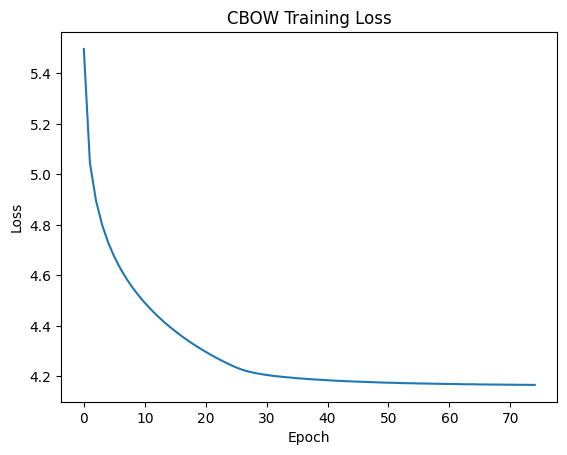

In [ ]:
plt.plot(history["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CBOW Training Loss")
plt.show()

### Toxic Comments Classifier Model

In [34]:
with open("word_to_idx.pkl", "rb") as f:
    word_to_idx = pickle.load(f)

with open("idx_to_word.pkl", "rb") as f:
    idx_to_word = pickle.load(f)

vocab_size = len(word_to_idx)

print("Vocabulary size:", vocab_size)

embedding_dim = 300
cbow_model = CBOW(vocab_size, embedding_dim).to(device)
cbow_model.load_state_dict(torch.load("best_cbow_model.pth"))

pretrained_weights = (cbow_model.embeddings.weight.data.clone())

Vocabulary size: 51017


In [35]:
def encode_comment(text, word_to_idx, max_len=300):
    tokens = text.split()

    ids = [
        word_to_idx.get(token, 0)
        for token in tokens
    ]

    ids = ids[:max_len]

    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))

    return ids

#### Preparing train and test loaders

In [36]:
class ToxicDataset(Dataset):
    def __init__(self, df, word_to_idx, max_len=300):
        self.df = df
        self.word_to_idx = word_to_idx
        self.max_len = max_len

        self.labels = [
            "toxic",
            "severe_toxic",
            "obscene",
            "threat",
            "insult",
            "identity_hate"
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = self.df.iloc[idx]["comment"]

        x = encode_comment(
            text,
            self.word_to_idx,
            self.max_len
        )

        y = self.df[self.labels].iloc[idx].to_numpy(dtype=np.float64)

        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y)
    )

In [37]:
class Classifier(nn.Module):

    def __init__(self, pretrained_weights):
        super().__init__()

        vocab_size, embed_dim = (pretrained_weights.shape)

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.embedding.weight.data.copy_(pretrained_weights)

        self.fc = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        embeds = self.embedding(x)
        pooled = embeds.mean(dim=1)
        out = self.fc(pooled)
        
        return out

In [38]:
train_set = ToxicDataset(TRAIN_SET, word_to_idx)
train_loader = DataLoader(train_set, batch_size=512, shuffle=True)

test_set = ToxicDataset(TEST_SET, word_to_idx)
test_loader = DataLoader(test_set, batch_size=512, shuffle=True)

#### Training & Evaluating

In [39]:
def evaluate_model(model, data_loader, device, pred_threshold=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5]):
    criterion = nn.BCEWithLogitsLoss()

    model.eval()

    total_loss = 0.0

    all_preds = []
    all_labels = []
    all_probs = []


    Progress_bar = tqdm(data_loader, desc="Evaluating ")
    thresholds = torch.tensor(pred_threshold).to(device)

    with torch.no_grad():
        for inputs, labels in Progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(outputs)

            preds = (probs > thresholds).float()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    avg_loss = total_loss / len(data_loader)

    all_probs = torch.cat(all_probs, dim=0)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    classes = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

    for i, cls in enumerate(classes):
        auc = roc_auc_score(
            all_labels[:, i].numpy(),
            all_probs[:, i].numpy()
        )
        print(f"{cls}: {auc:.4f}")

    auc = roc_auc_score(all_labels.numpy(), all_probs.numpy(), average="macro")
    f1_micro = f1_score(all_labels.numpy(), all_preds.numpy(), average="micro")
    f1_macro = f1_score(all_labels.numpy(), all_preds.numpy(), average="macro")
    print(f"Macro ROC-AUC: {auc:.4f}")
    print(f"Micro F1: {f1_micro:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")

    return auc, (avg_loss, all_preds, all_labels, all_probs)

In [60]:
def train_classifier(model, train_loader, test_loader, num_epochs, device, lr=1e-3):

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)
    
    best_auc = float("-inf")

    patience_counter = 0
    
    train_loss = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        print("\n")
        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}"
        )

        for comment, labels in progress_bar:
            comment = comment.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(comment)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            # live display of loss
            progress_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}"
            )

        avg_loss = total_loss / len(train_loader)

        train_loss.append(avg_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Loss: {avg_loss:.4f}"
        )
        
        auc, _ = evaluate_model(model, test_loader, device)

        if auc > best_auc:
            patience_counter = 0
            best_auc = auc

            torch.save(
                model.state_dict(),
                "cls_model.pth"
            )
        else:
            patience_counter+=1
        
        if patience_counter >= 3:
            break

    return train_loss

In [61]:
toxic_classifier = Classifier(pretrained_weights)
train_loss = train_classifier(toxic_classifier, train_loader, test_loader, 25, device)

Epoch 1/25: 100%|██████████| 312/312 [04:38<00:00,  1.12it/s, batch_loss=0.0693]


Epoch [1/25] Loss: 0.1263


Evaluating : 100%|██████████| 125/125 [00:43<00:00,  2.88it/s]


toxic: 0.9080
severe_toxic: 0.9717
obscene: 0.9261
threat: 0.9251
insult: 0.9288
identity_hate: 0.9192
Macro ROC-AUC: 0.9298
Micro F1: 0.3782
Macro F1: 0.2209




Epoch 2/25: 100%|██████████| 312/312 [04:35<00:00,  1.13it/s, batch_loss=0.0633]


...

toxic: 0.9495
severe_toxic: 0.9866
obscene: 0.9661
threat: 0.9612
insult: 0.9596
identity_hate: 0.9514
Macro ROC-AUC: 0.9624
Micro F1: 0.5800
Macro F1: 0.3694




Epoch 18/25: 100%|██████████| 312/312 [04:18<00:00,  1.21it/s, batch_loss=0.0352]


Epoch [18/25] Loss: 0.0378


Evaluating : 100%|██████████| 125/125 [00:40<00:00,  3.09it/s]

toxic: 0.9533
severe_toxic: 0.9856
obscene: 0.9683
threat: 0.9647
insult: 0.9622
identity_hate: 0.9542
Macro ROC-AUC: 0.9647
Micro F1: 0.6344
Macro F1: 0.4365


### Results

In [40]:
cls_model = Classifier(pretrained_weights).to(device)
cls_model.load_state_dict(torch.load("cls_model.pth"))

#thresholds = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
auc, (avg_loss, all_preds, all_labels, all_probs) = evaluate_model(cls_model, test_loader, device)#, thresholds)

Evaluating : 100%|██████████| 125/125 [01:12<00:00,  1.73it/s]

toxic: 0.9546
severe_toxic: 0.9857
obscene: 0.9686
threat: 0.9632
insult: 0.9626
identity_hate: 0.9538
Macro ROC-AUC: 0.9648
Micro F1: 0.6345
Macro F1: 0.4340


#### Precision, Recall & F1 with prediction threshold > 0.5

In [41]:
print(
    classification_report(
        all_labels.numpy(),
        all_preds.numpy(),
        target_names=labels,
        zero_division=0
    )
)

               precision    recall  f1-score   support

        toxic       0.58      0.78      0.67      6090
 severe_toxic       0.47      0.38      0.42       367
      obscene       0.69      0.67      0.68      3691
       threat       0.43      0.01      0.03       211
       insult       0.61      0.62      0.61      3427
identity_hate       0.52      0.12      0.20       712

    micro avg       0.61      0.66      0.63     14498
    macro avg       0.55      0.43      0.43     14498
 weighted avg       0.61      0.66      0.62     14498
  samples avg       0.07      0.06      0.06     14498



In [42]:
best_thresholds = {}

for i, cls in enumerate(labels):
    y_true = all_labels[:, i].numpy()
    y_prob = all_probs[:, i].numpy()

    best_f1 = 0
    best_thr = 0.5

    for thr in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_prob >= thr).astype(int)

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    print(
        f"{cls:15} "
        f"threshold={best_thr:.2f} "
        f"F1={best_f1:.4f}"
    )

    best_thresholds[cls] = best_thr

toxic           threshold=0.65 F1=0.6794
severe_toxic    threshold=0.45 F1=0.4476
obscene         threshold=0.45 F1=0.6854
threat          threshold=0.10 F1=0.2339
insult          threshold=0.44 F1=0.6159
identity_hate   threshold=0.27 F1=0.3667


In [43]:
best_thresh = [0.65, 0.45, 0.45, 0.10, 0.44, 0.27]
auc, (avg_loss, all_preds, all_labels, all_probs) = evaluate_model(cls_model, test_loader, device, best_thresh)
print("\n")
print(
    classification_report(
        all_labels.numpy(),
        all_preds.numpy(),
        target_names=labels,
        zero_division=0
    )
)

Evaluating : 100%|██████████| 125/125 [01:07<00:00,  1.86it/s]

toxic: 0.9546
severe_toxic: 0.9857
obscene: 0.9686
threat: 0.9632
insult: 0.9626
identity_hate: 0.9538
Macro ROC-AUC: 0.9648
Micro F1: 0.6347
Macro F1: 0.5048


               precision    recall  f1-score   support

        toxic       0.64      0.72      0.68      6090
 severe_toxic       0.43      0.47      0.45       367
      obscene       0.67      0.70      0.69      3691
       threat       0.18      0.33      0.23       211
       insult       0.57      0.66      0.62      3427
identity_hate       0.32      0.42      0.37       712

    micro avg       0.60      0.68      0.63     14498
    macro avg       0.47      0.55      0.50     14498
 weighted avg       0.61      0.68      0.64     14498
  samples avg       0.06      0.06      0.06     14498



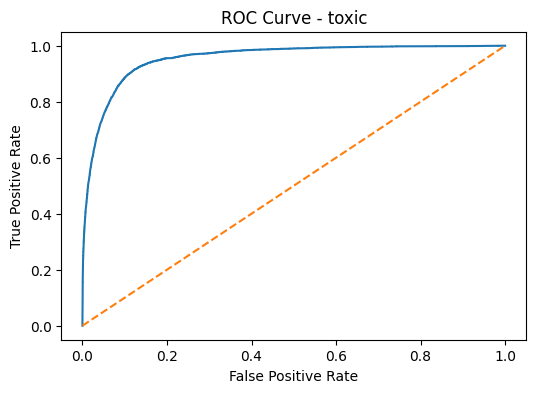

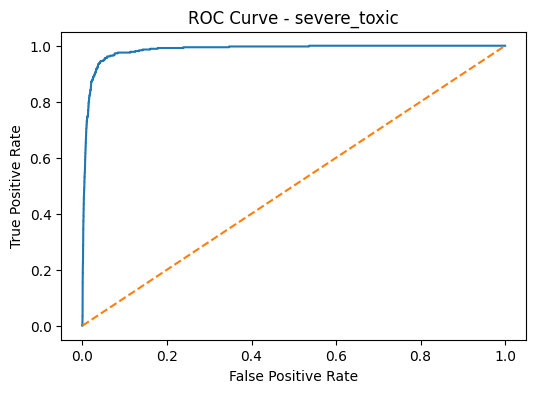

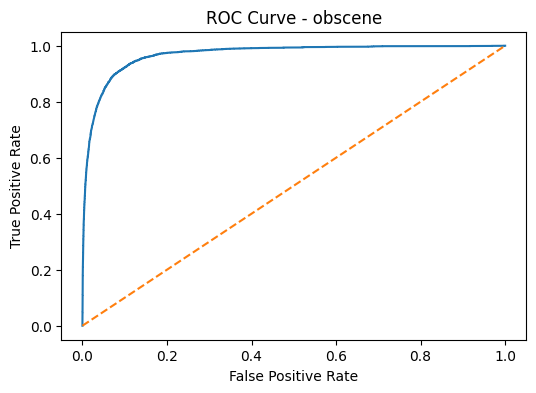

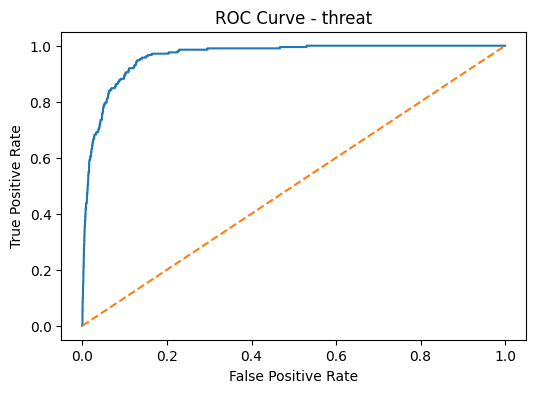

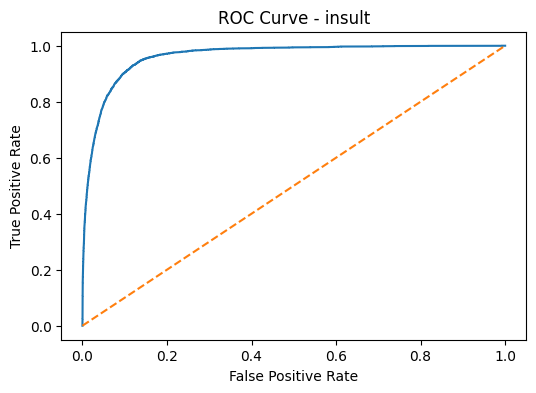

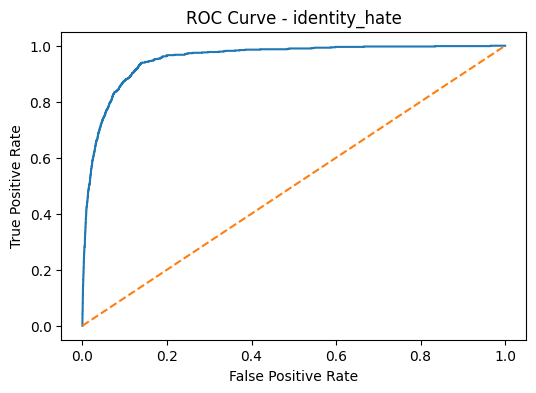

In [44]:
for i, cls in enumerate(labels):
    fpr, tpr, _ = roc_curve(
        all_labels[:, i].numpy(),
        all_probs[:, i].numpy()
    )

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.title(f"ROC Curve - {cls}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()